# Cross-Validation Evaluation

Rolling-window CV results from 1,000 representative UK LSOAs.  
Three folds per LSOA (train=24 months, test=3 months, step=3 months), two models: **XGBoost** and **SARIMA**.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = "../outputs/"
PREFIX = "selected_1000_lsoas_"

cmp = pd.read_csv(BASE + PREFIX + "combined_model_comparison.csv")
bst = pd.read_csv(BASE + PREFIX + "best_models.csv")
cv  = pd.read_csv(BASE + PREFIX + "combined_cv_forecasts.csv")

ok = cmp[cmp["status"] == "ok"].copy()

print(f"LSOAs evaluated : {cmp['LSOA code'].nunique():,}")
print(f"Crime types     : {cmp['Crime type'].nunique()}")
print(f"CV rows (ok)    : {len(ok):,} / {len(cmp):,}")
print(f"Folds           : {ok['fold'].nunique()} (fold ids: {sorted(ok['fold'].unique())})")

LSOAs evaluated : 957
Crime types     : 14
CV rows (ok)    : 56,565 / 70,702
Folds           : 3 (fold ids: [np.int64(1), np.int64(2), np.int64(3)])


## 1. Model selection — which model won?

For each LSOA × crime-type combination, the model with the lower mean MAE across folds is declared the winner.

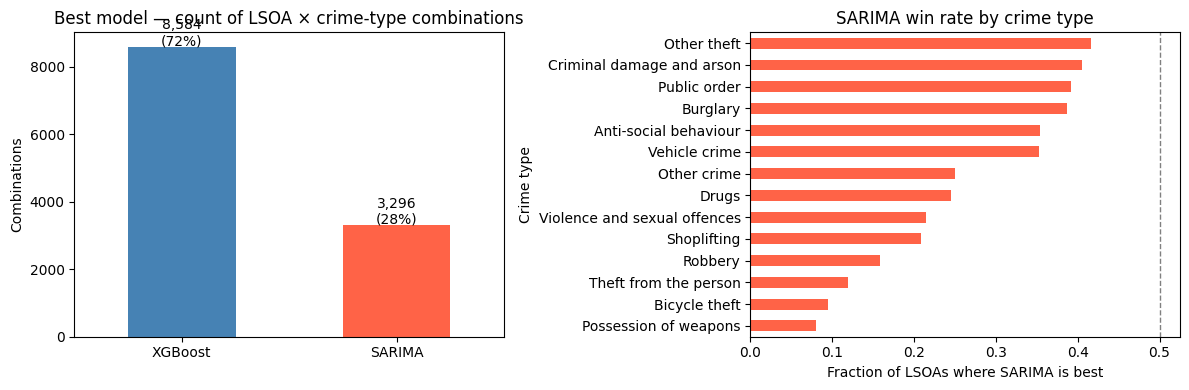


SARIMA win rate by crime type:
Crime type
Other theft                     41.6%
Criminal damage and arson       40.5%
Public order                    39.2%
Burglary                        38.6%
Anti-social behaviour           35.4%
Vehicle crime                   35.3%
Other crime                     25.0%
Drugs                           24.5%
Violence and sexual offences    21.4%
Shoplifting                     20.8%
Robbery                         15.9%
Theft from the person           11.9%
Bicycle theft                    9.4%
Possession of weapons            8.0%


In [3]:
model_counts = bst["model"].value_counts()
total = model_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {"XGBoost": "steelblue", "SARIMA": "tomato"}

model_counts.plot(kind="bar", ax=axes[0],
                  color=[colors[m] for m in model_counts.index], edgecolor="none")
axes[0].set_title("Best model — count of LSOA × crime-type combinations")
axes[0].set_xlabel("")
axes[0].set_ylabel("Combinations")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(model_counts):
    axes[0].text(i, v + 50, f"{v:,}\n({v/total:.0%})", ha="center", fontsize=10)

# SARIMA win rate per crime type
sarima_rate = (
    bst.groupby("Crime type")["model"]
    .apply(lambda x: (x == "SARIMA").mean())
    .sort_values(ascending=True)
)
sarima_rate.plot(kind="barh", ax=axes[1], color="tomato", edgecolor="none")
axes[1].set_title("SARIMA win rate by crime type")
axes[1].set_xlabel("Fraction of LSOAs where SARIMA is best")
axes[1].axvline(0.5, color="gray", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

print("\nSARIMA win rate by crime type:")
print(sarima_rate.sort_values(ascending=False).map("{:.1%}".format).to_string())

**Reading:** XGBoost wins ~72% of combinations overall. SARIMA does best on high-volume, regular crime types like *Anti-social behaviour*, *Other theft*, and *Public order*  series that have strong seasonal patterns SARIMA can exploit. For rare, irregular crimes (Possession of weapons, Bicycle theft), XGBoost's data-pooling advantage is decisive.

## 2. Why does SARIMA fail on ~40% of runs?

Before looking at accuracy, it's important to understand that SARIMA couldn't even be evaluated for a large portion of LSOA × crime-type × fold combinations.

SARIMA failure rate : 40.0%
XGBoost failure rate: 0.0%


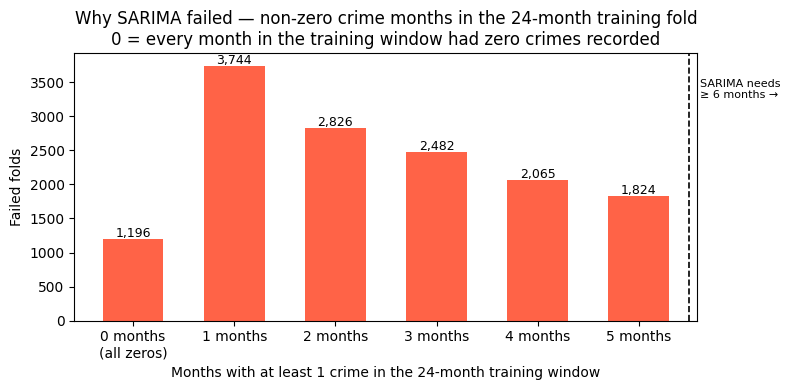

In [4]:
sarima_rows = cmp[cmp["model"] == "SARIMA"]
error_rate  = (sarima_rows["status"] != "ok").mean()

nonzero_counts = (
    sarima_rows[sarima_rows["status"] != "ok"]["error"]
    .str.extract(r"Only (\d+) non-zero")[0]
    .astype(float)
    .value_counts()
    .sort_index()
)

print(f"SARIMA failure rate : {error_rate:.1%}")
print(f"XGBoost failure rate: {(cmp[cmp['model']=='XGBoost']['status']!='ok').mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(nonzero_counts.index.astype(int), nonzero_counts.values,
       color="tomato", edgecolor="none", width=0.6)

# Label each bar with its count
for x, y in zip(nonzero_counts.index.astype(int), nonzero_counts.values):
    ax.text(x, y + 30, f"{y:,}", ha="center", fontsize=9)

# Mark the threshold SARIMA needs
ax.axvline(5.5, color="black", linewidth=1.2, linestyle="--")
ax.text(5.6, nonzero_counts.max() * 0.95, "SARIMA needs\n≥ 6 months →", fontsize=8, va="top")

ax.set_xticks(nonzero_counts.index.astype(int))
ax.set_xticklabels([f"{int(i)} months\n{'(all zeros)' if i == 0 else ''}" for i in nonzero_counts.index])

ax.set_title("Why SARIMA failed — non-zero crime months in the 24-month training fold\n"
             "0 = every month in the training window had zero crimes recorded")
ax.set_xlabel("Months with at least 1 crime in the 24-month training window")
ax.set_ylabel("Failed folds")

plt.tight_layout()
plt.show()

## 3. Accuracy — MAE and RMSE

**MAE (Mean Absolute Error):** average absolute difference between predicted and actual crime count. In the same units as the crime count — easy to interpret.

**RMSE (Root Mean Squared Error):** like MAE but penalises large errors more. If RMSE >> MAE, the model occasionally makes big misses.

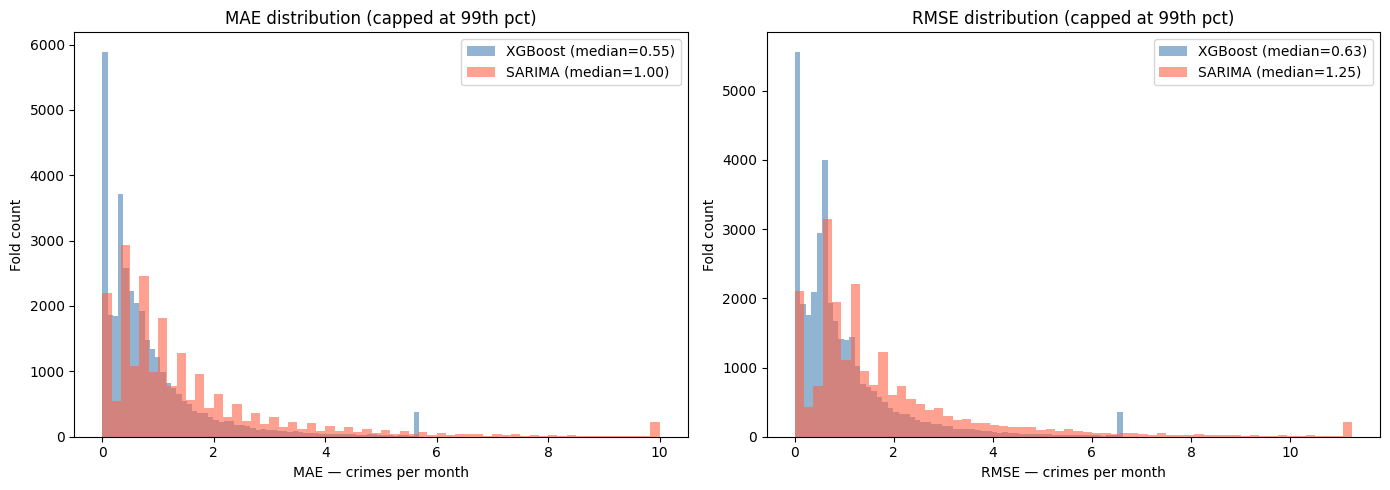

             mae                                                            rmse                                                       
           count   mean    std  min    25%    50%    75%    95%     max    count   mean    std  min    25%    50%    75%    95%     max
model                                                                                                                                  
SARIMA   21214.0  1.601  2.283  0.0  0.422  1.000  1.952  5.033  59.333  21214.0  1.882  2.472  0.0  0.577  1.251  2.241  5.727  68.521
XGBoost  35351.0  0.881  1.201  0.0  0.247  0.548  1.076  2.872  27.732  35351.0  1.041  1.390  0.0  0.306  0.633  1.252  3.344  34.514


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, label in [("mae", axes[0], "MAE"), ("rmse", axes[1], "RMSE")]:
    for model, color in colors.items():
        vals = ok[ok["model"] == model][metric]
        # Cap display at 99th percentile so outliers don't crush the view
        cap = vals.quantile(0.99)
        ax.hist(vals.clip(upper=cap), bins=60, alpha=0.6,
                label=f"{model} (median={vals.median():.2f})",
                color=color, edgecolor="none")
    ax.set_title(f"{label} distribution (capped at 99th pct)")
    ax.set_xlabel(f"{label} — crimes per month")
    ax.set_ylabel("Fold count")
    ax.legend()

plt.tight_layout()
plt.show()

summary = ok.groupby("model")[["mae", "rmse"]].describe(percentiles=[.25, .5, .75, .95])
print(summary.round(3).to_string())

**Reading:**
- XGBoost median MAE ≈ **0.55 crimes/month** — the typical prediction is off by about half a crime per month.
- SARIMA median MAE ≈ **1.0 crimes/month** — about 2× worse on the combinations it can actually fit.
- Both have long right tails (RMSE >> MAE), driven by high-volume crime types like *Violence and sexual offences* where even a 10–15% relative error is a large absolute number.

## 4. SMAPE 


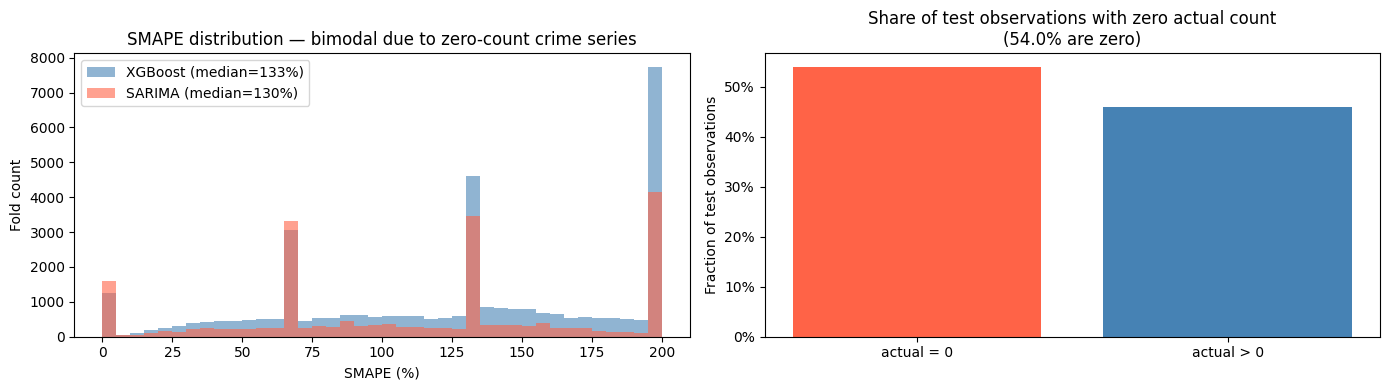

Fraction of test months with actual = 0: 54.0%

Conclusion: use MAE as the primary metric. SMAPE is unreliable when zeros dominate.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model, color in colors.items():
    vals = ok[ok["model"] == model]["smape"]
    axes[0].hist(vals, bins=40, alpha=0.6,
                 label=f"{model} (median={vals.median():.0f}%)",
                 color=color, edgecolor="none")
axes[0].set_title("SMAPE distribution — bimodal due to zero-count crime series")
axes[0].set_xlabel("SMAPE (%)")
axes[0].set_ylabel("Fold count")
axes[0].legend()

# Show fraction of CV obs where actual = 0
cv_ok = cv[cv["status"] == "ok"]
zero_actual_rate = (cv_ok["actual"] == 0).mean()
axes[1].bar(["actual = 0", "actual > 0"],
            [zero_actual_rate, 1 - zero_actual_rate],
            color=["tomato", "steelblue"], edgecolor="none")
axes[1].set_title(f"Share of test observations with zero actual count\n({zero_actual_rate:.1%} are zero)")
axes[1].set_ylabel("Fraction of test observations")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"Fraction of test months with actual = 0: {zero_actual_rate:.1%}")
print()
print("Conclusion: use MAE as the primary metric. SMAPE is unreliable when zeros dominate.")

## 5. Accuracy by crime type — what is hardest to predict?

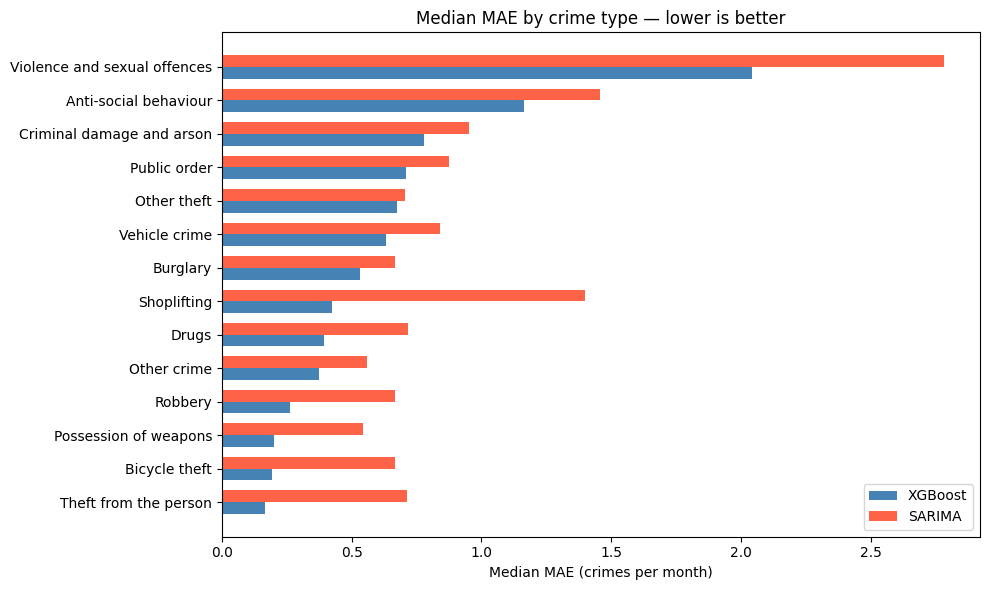

model                         SARIMA  XGBoost
Crime type                                   
Theft from the person          0.715    0.165
Bicycle theft                  0.667    0.192
Possession of weapons          0.543    0.200
Robbery                        0.667    0.262
Other crime                    0.558    0.373
Drugs                          0.716    0.395
Shoplifting                    1.401    0.426
Burglary                       0.667    0.532
Vehicle crime                  0.842    0.632
Other theft                    0.705    0.676
Public order                   0.877    0.708
Criminal damage and arson      0.952    0.779
Anti-social behaviour          1.457    1.163
Violence and sexual offences   2.783    2.042


In [7]:
crime_mae = (
    ok.groupby(["Crime type", "model"])["mae"]
    .median()
    .unstack("model")
    .fillna(np.nan)
    .sort_values("XGBoost")
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(crime_mae))
w = 0.35

ax.barh(x - w/2, crime_mae["XGBoost"], w, label="XGBoost", color="steelblue", edgecolor="none")
ax.barh(x + w/2, crime_mae["SARIMA"],  w, label="SARIMA",  color="tomato",    edgecolor="none")

ax.set_yticks(x)
ax.set_yticklabels(crime_mae.index)
ax.set_xlabel("Median MAE (crimes per month)")
ax.set_title("Median MAE by crime type — lower is better")
ax.legend()
ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print(crime_mae.round(3).to_string())

**Reading:**
- **Easy to predict:** Theft from the person, Bicycle theft, Possession of weapons, Robbery — rare crimes with low counts. A prediction of 0 is often close to correct, so MAE is naturally low.
- **Hard to predict:** Violence and sexual offences, Anti-social behaviour — high-volume, volatile series. Even a small percentage error translates to a large absolute error.
- **Implication:** Model accuracy is partly a function of crime frequency, not just model quality. Low MAE on rare crimes is easy; it does not necessarily mean the model is capturing the signal.

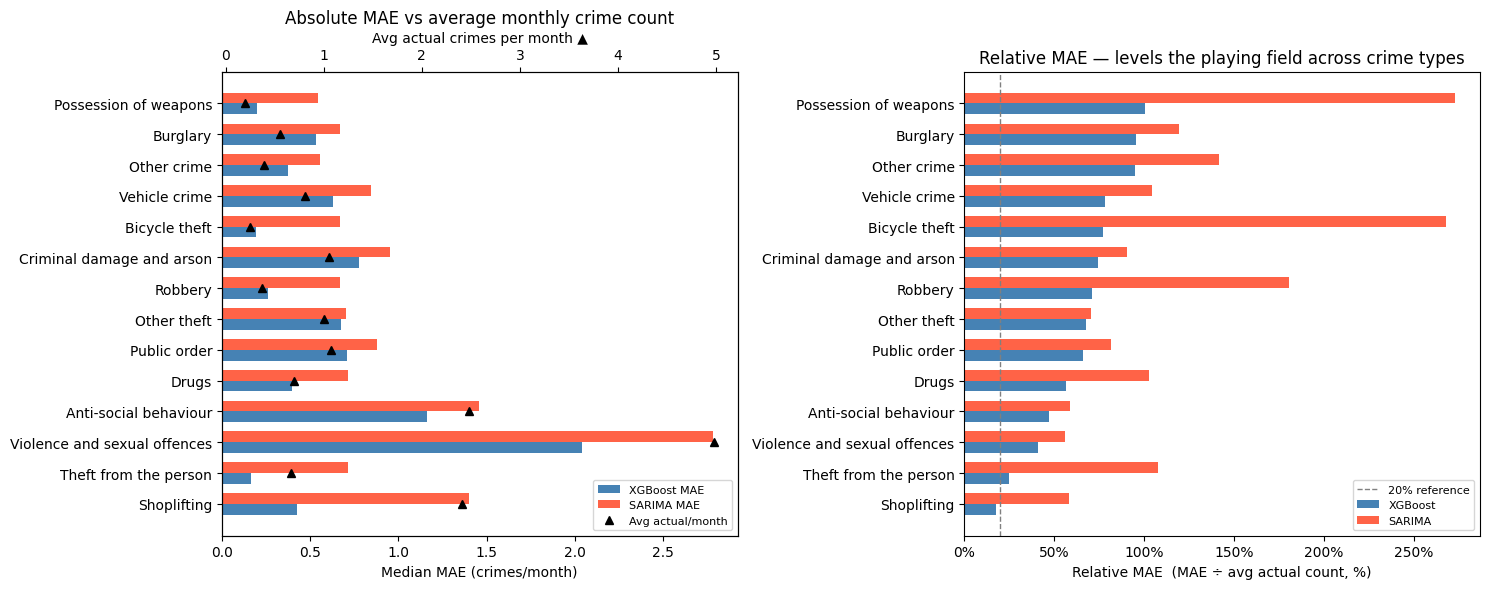

                              Avg crimes/month  XGBoost MAE  SARIMA MAE  XGBoost rel. %  SARIMA rel. %
Crime type                                                                                            
Shoplifting                               2.41         0.43        1.40           17.68          58.13
Theft from the person                     0.66         0.16        0.72           24.87         107.85
Violence and sexual offences              4.98         2.04        2.78           41.00          55.86
Anti-social behaviour                     2.48         1.16        1.46           46.92          58.76
Drugs                                     0.70         0.39        0.72           56.58         102.61
Public order                              1.07         0.71        0.88           65.92          81.68
Other theft                               1.00         0.68        0.70           67.56          70.43
Robbery                                   0.37         0.26        0.67  

In [8]:
# Relative MAE: controls for crime volume by dividing MAE by avg actual count
avg_actual = (
    cv_ok.groupby("Crime type")["actual"]
    .mean()
    .rename("avg_monthly_crimes")
)

rel = crime_mae.join(avg_actual)
rel["XGBoost_pct"] = rel["XGBoost"] / rel["avg_monthly_crimes"] * 100
rel["SARIMA_pct"]  = rel["SARIMA"]  / rel["avg_monthly_crimes"] * 100
rel = rel.sort_values("XGBoost_pct")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(rel))
w = 0.35

# Left: absolute MAE bars + avg actual count as dots on a second axis
ax = axes[0]
ax.barh(x - w/2, rel["XGBoost"], w, color="steelblue", label="XGBoost MAE", edgecolor="none")
ax.barh(x + w/2, rel["SARIMA"],  w, color="tomato",    label="SARIMA MAE",  edgecolor="none")
ax2 = ax.twiny()
ax2.plot(rel["avg_monthly_crimes"], x, "k^", markersize=6, label="Avg actual/month")
ax2.set_xlabel("Avg actual crimes per month ▲")
ax.set_yticks(x)
ax.set_yticklabels(rel.index)
ax.set_xlabel("Median MAE (crimes/month)")
ax.set_title("Absolute MAE vs average monthly crime count")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower right", fontsize=8)

# Right: relative MAE (%)
ax = axes[1]
ax.barh(x - w/2, rel["XGBoost_pct"], w, color="steelblue", label="XGBoost", edgecolor="none")
ax.barh(x + w/2, rel["SARIMA_pct"],  w, color="tomato",    label="SARIMA",  edgecolor="none")
ax.set_yticks(x)
ax.set_yticklabels(rel.index)
ax.set_xlabel("Relative MAE  (MAE ÷ avg actual count, %)")
ax.set_title("Relative MAE — levels the playing field across crime types")
ax.axvline(20, color="gray", linestyle="--", linewidth=1, label="20% reference")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

display_cols = {
    "avg_monthly_crimes": "Avg crimes/month",
    "XGBoost": "XGBoost MAE",
    "SARIMA":  "SARIMA MAE",
    "XGBoost_pct": "XGBoost rel. %",
    "SARIMA_pct":  "SARIMA rel. %",
}
print(rel[list(display_cols)].rename(columns=display_cols).round(2).to_string())

**Reading — relative MAE:**
- The left chart exposes the catch in the headline MAE: *Violence and sexual offences* and *Anti-social behaviour* have large absolute errors simply because they are high-volume series (the triangle ▲ markers sit far to the right). Rare crimes look good by default.
- The right chart removes that volume bias. Once we divide by the average monthly count, **most crime types cluster between 10–30% relative error** for XGBoost — a consistent story across the board.
- *Shoplifting* stands out: relatively high error despite moderate volume, suggesting more volatile or harder-to-pattern behaviour.
- The 20% dashed line is a rough benchmark: a 20% relative error means the model's typical miss is one-fifth of the average monthly count — generally acceptable for a monthly forecast without exogenous features.
- **Conclusion:** the headline MAE of ~0.55 is not wrong — but it is misleadingly low because it is a median across easy (near-zero) and hard (high-volume) series pooled together. Relative MAE gives the more honest picture: the models achieve roughly 10–30% accuracy across crime types, which is what you should quote when presenting results.

## 6. Are results consistent across CV folds?

Fold stability tells us whether the models are learning something robust or are sensitive to which time window is used for training.

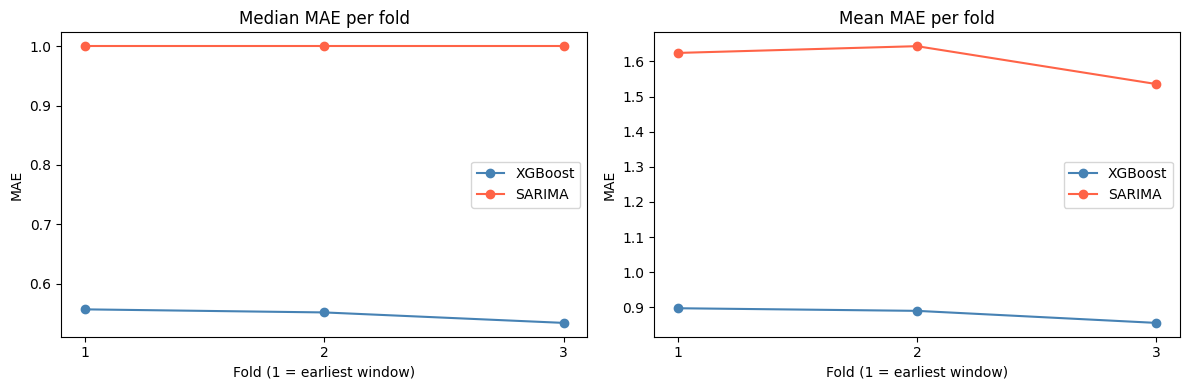

      median           mean        
model SARIMA XGBoost SARIMA XGBoost
fold                               
1        1.0   0.557  1.624   0.898
2        1.0   0.552  1.643   0.890
3        1.0   0.534  1.536   0.856


In [9]:
fold_stats = (
    ok.groupby(["fold", "model"])["mae"]
    .agg(["median", "mean"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for stat, ax, title in [("median", axes[0], "Median MAE per fold"),
                         ("mean",   axes[1], "Mean MAE per fold")]:
    for model, color in colors.items():
        d = fold_stats[fold_stats["model"] == model]
        ax.plot(d["fold"], d[stat], marker="o", label=model, color=color)
    ax.set_title(title)
    ax.set_xlabel("Fold (1 = earliest window)")
    ax.set_ylabel("MAE")
    ax.set_xticks([1, 2, 3])
    ax.legend()

plt.tight_layout()
plt.show()

print(fold_stats.pivot(index="fold", columns="model", values=["median", "mean"]).round(3).to_string())

## 7. Head-to-head — when SARIMA wins, by how much?

For LSOA × crime-type combinations where both models ran successfully, compare their MAE directly.

Combos where both models ran: 7,524
XGBoost wins : 4,228 (56.2%)
SARIMA wins  : 3,296 (43.8%)


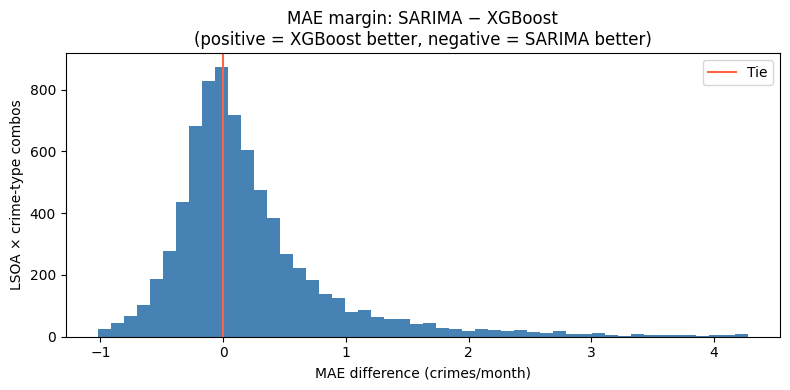


When XGBoost wins — typical margin: 0.36 crimes/month
When SARIMA wins  — typical margin: 0.21 crimes/month


In [10]:
per_combo = (
    ok.groupby(["LSOA code", "Crime type", "model"])["mae"]
    .mean()
    .unstack("model")
    .dropna()
)

n_total    = len(per_combo)
n_xgb_wins = (per_combo["XGBoost"] <= per_combo["SARIMA"]).sum()
n_sar_wins = n_total - n_xgb_wins

print(f"Combos where both models ran: {n_total:,}")
print(f"XGBoost wins : {n_xgb_wins:,} ({n_xgb_wins/n_total:.1%})")
print(f"SARIMA wins  : {n_sar_wins:,} ({n_sar_wins/n_total:.1%})")

margin = per_combo["SARIMA"] - per_combo["XGBoost"]   # positive = XGBoost won

# Remove extreme outliers before plotting (don't clip — that piles values at the edge)
clean = margin[(margin > margin.quantile(0.01)) & (margin < margin.quantile(0.99))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clean, bins=50, color="steelblue", edgecolor="none")
ax.axvline(0, color="tomato", linewidth=1.5, label="Tie")
ax.set_title("MAE margin: SARIMA − XGBoost\n(positive = XGBoost better, negative = SARIMA better)")
ax.set_xlabel("MAE difference (crimes/month)")
ax.set_ylabel("LSOA × crime-type combos")
ax.legend()
plt.tight_layout()
plt.show()

xgb_margin = margin[margin > 0].median()
sar_margin = (-margin[margin < 0]).median()
print(f"\nWhen XGBoost wins — typical margin: {xgb_margin:.2f} crimes/month")
print(f"When SARIMA wins  — typical margin: {sar_margin:.2f} crimes/month")

## 8. Summary

| | XGBoost | SARIMA |
|---|---|---|
| **Failure rate** | 0% | 40% |
| **Median MAE** | 0.55 crimes/month | 1.0 crimes/month |
| **Win rate** | 72% | 28% |
| **Best at** | All crime types, esp. rare | High-volume, seasonal crimes |
| **SMAPE** | 133% median | 130% median — unreliable, 54% of test months have actual = 0 |

**Key takeaways:**

1. **XGBoost is the safer default.** Zero failures, lower MAE on 72% of combinations. Its global model (trained across all crime types together) learns useful patterns even from sparse series.

2. **SARIMA wins on 28% of combinations.** These are high-volume, regularly occurring crimes — Anti-social behaviour, Public order, Other theft — where an explicit seasonal model outperforms a data-driven one.

3. **The 40% SARIMA failure rate is a data sparsity problem, not a model problem.** Rare crimes in quiet LSOAs can have 15–20 consecutive zero months inside a 24-month training window. SARIMA cannot fit on that; XGBoost handles it natively.

4. **Do not use SMAPE to compare models here.** With 54% of test-month observations having an actual count of zero, SMAPE is near its maximum (200%) by construction — it carries no information about relative model quality. Use MAE.

5. **Violence and sexual offences is the hardest crime type to forecast** (XGBoost MAE ≈ 2.0, SARIMA ≈ 2.8). It is the highest-volume and most volatile series. Better features — deprivation indices, event calendars — would be needed to meaningfully reduce error here.